# Practical Statistics for Data Scientists (Python + R)
# Chapter 3. Statistical Experiments and Significance Testing
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck

## Loading the rpy2 extension in a notebook with the Python kernel

In [1]:
import sys
import io

stderr_original = sys.stderr
sys.stderr = io.StringIO()

# Loading the extension without noise
%load_ext rpy2.ipython

sys.stderr = stderr_original  # Restore silently

In [2]:
%%R
suppressWarnings(
  invisible(
    try(Sys.setlocale("LC_ALL", "English"), silent = TRUE)
  )
)

## Import packages

### Import required Python packages.

In [3]:
%matplotlib inline

from pathlib import Path
import random

import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import power

import matplotlib.pylab as plt

In [4]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

### Import required R packages

In [5]:
%%R
Sys.setlocale("LC_ALL", "English")
# Install missing packages if needed
packages <- c("ggplot2", "dplyr", "lmPerm", "pwr")
installed <- rownames(installed.packages())
to_install <- packages[!packages %in% installed]
if (length(to_install) > 0) {
  install.packages(to_install, repos = 'https://cloud.r-project.org/')
}

# Load them all
library(ggplot2)
library(dplyr)
library(lmPerm)
library(pwr)


Dolaczanie pakietu: 'dplyr'

Nastepujace obiekty zostaly zakryte z 'package:stats':

    filter, lag

Nastepujace obiekty zostaly zakryte z 'package:base':

    intersect, setdiff, setequal, union

In addition: Warning messages:
1: pakiet 'lmPerm' zostal zbudowany w wersji R 4.5.3 
2: pakiet 'pwr' zostal zbudowany w wersji R 4.5.3 


## Defining data paths
If you don't keep your data in the same directory as the code, adapt the path names.

### Python

In [6]:
WEB_PAGE_DATA_CSV = DATA / 'web_page_data.csv'
FOUR_SESSIONS_CSV = DATA / 'four_sessions.csv'
CLICK_RATE_CSV = DATA / 'click_rates.csv'
IMANISHI_CSV = DATA / 'imanishi_data.csv'

### R
R loads the same Chapter 3 datasets from disk (`web_page_data`, `four_sessions`, `click_rates`, and `imanishi_data`) and applies the same time scaling as Python.

In [7]:
%%R
PSDS_PATH <- file.path(dirname(dirname(getwd())))


session_times <- read.csv(file.path(PSDS_PATH, 'data', 'web_page_data.csv'))
session_times[,2] <- session_times[,2] * 100
four_sessions  <- read.csv(file.path(PSDS_PATH, 'data', 'four_sessions.csv'))
click_rate <-  read.csv(file.path(PSDS_PATH, 'data', 'click_rates.csv'))
imanishi <-  read.csv(file.path(PSDS_PATH, 'data', 'imanishi_data.csv'))

### Summary: Defining data paths

| Operation | Python | R | Notes |
|---|---|---|---|
| Base path setup | `Path(...)` / explicit strings | direct path strings in `read.csv()` | Both point to the same chapter datasets. |
| Dataset loading | `pd.read_csv(...)` | `read.csv(...)` | Equivalent import step with language-specific defaults. |
| Basic preprocessing | pandas column transforms | base R column transforms | Both align units before analysis. |

Python makes path handling and transformations explicit through objects, while R keeps data import and quick preprocessing concise.

# Resampling

In [8]:
session_times = pd.read_csv(WEB_PAGE_DATA_CSV)
session_times.Time = 100 * session_times.Time

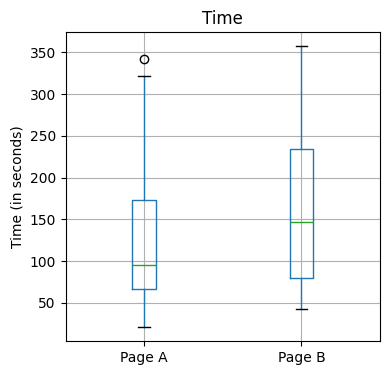

In [9]:
ax = session_times.boxplot(by='Page', column='Time',
                           figsize=(4, 4))
ax.set_xlabel('')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')

plt.tight_layout()
plt.show()

In [10]:
mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()
print(mean_b - mean_a)

35.66666666666667


The following code is different to the R version. idx_A and idx_B are reversed.

In [11]:
# Permutation test example with stickiness
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()
    
nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]
print(perm_fun(session_times.Time, nA, nB))

30.752380952380946


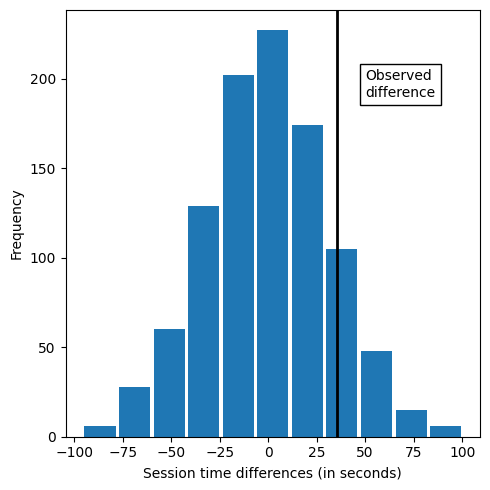

In [12]:
random.seed(1)
perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x = mean_b - mean_a, color='black', lw=2)
ax.text(50, 190, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Session time differences (in seconds)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [13]:
# convert perm_diffs to numpy array to avoid problems with some Python installations
perm_diffs = np.array(perm_diffs)
print(np.mean(perm_diffs > mean_b - mean_a))

0.121


### R
R reproduces the permutation workflow using a custom `perm_fun`, then visualizes the null distribution and computes the one-sided tail probability.

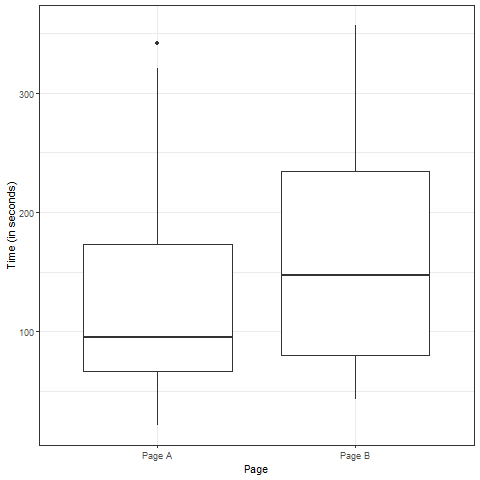

In [14]:
%%R
graph <- ggplot(session_times, aes(x=Page, y=Time)) + 
  geom_boxplot() +
  labs(y='Time (in seconds)') + 
  theme_bw()
graph

In [15]:
%%R
mean_a <- mean(session_times[session_times['Page'] == 'Page A', 'Time'])
mean_b <- mean(session_times[session_times['Page'] == 'Page B', 'Time'])
mean_b - mean_a

[1] 35.66667


In [16]:
%%R
## Permutation test example with stickiness
perm_fun <- function(x, nA, nB)
{
  n <- nA + nB
  idx_b <- sample(1:n, nB)
  idx_a <- setdiff(1:n, idx_b)
  mean_diff <- mean(x[idx_b]) - mean(x[idx_a])
  return(mean_diff)
}

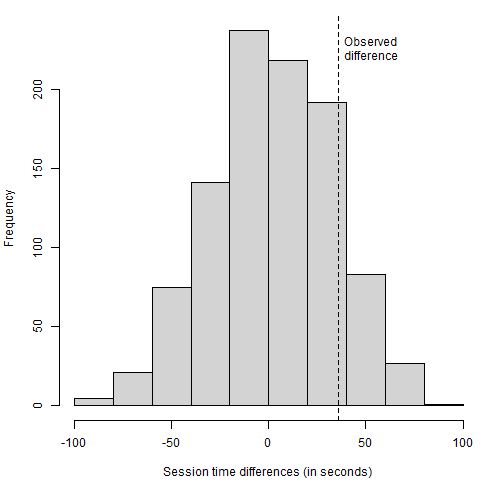

In [17]:
%%R
set.seed(1)
perm_diffs <- rep(0, 1000)
for (i in 1:1000) {
  perm_diffs[i] = perm_fun(session_times[, 'Time'], 21, 15)
}
par(mar=c(4,4,1,0)+.1)
hist(perm_diffs, xlab='Session time differences (in seconds)', main='')
abline(v=mean_b - mean_a, lty=2, lwd=1.5)
text('  Observed\n  difference', x=mean_b - mean_a,  y=par()$usr[4]-20, adj=0)

In [18]:
%%R
mean(perm_diffs > (mean_b - mean_a))

[1] 0.141


### Summary: Resampling

| Operation | Python | R | Notes |
|---|---|---|---|
| Group comparison plot | `DataFrame.boxplot()` | `ggplot2::geom_boxplot()` | Both inspect between-page session-time differences visually. |
| Permutation function | custom `perm_fun()` with `random.sample()` | custom `perm_fun()` with `sample()` | Same logic with language-specific sampling utilities. |
| Null distribution simulation | list comprehension over 1000 permutations | `for` loop over 1000 permutations | Equivalent Monte Carlo approach. |
| Empirical tail probability | `np.mean(perm_diffs > observed_diff)` | `mean(perm_diffs > observed_diff)` | Same p-value-style estimate from permutation outcomes. |

Python and R follow the same permutation-test design, but Python is more array/list oriented while R is more vectorized and formula-friendly.

# Statistical Significance and P-Values

Observed difference: 0.0368%


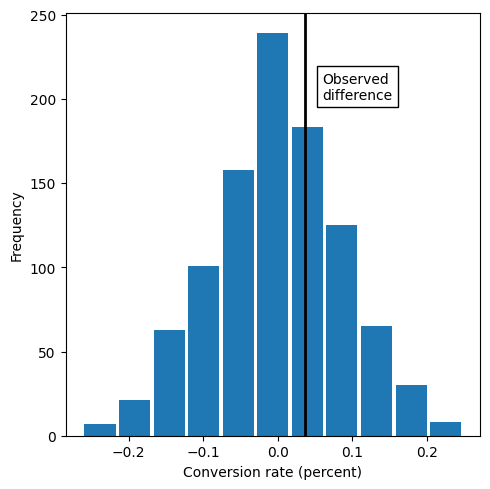

In [19]:
random.seed(1)
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f'Observed difference: {obs_pct_diff:.4f}%')
conversion = [0] * 45945
conversion.extend([1] * 382)
conversion = pd.Series(conversion)

perm_diffs = [100 * perm_fun(conversion, 23739, 22588) 
              for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=obs_pct_diff, color='black', lw=2)
ax.text(0.06, 200, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Conversion rate (percent)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### R
R computes the observed conversion-rate difference and generates a permutation-based null distribution using repeated random shuffles.

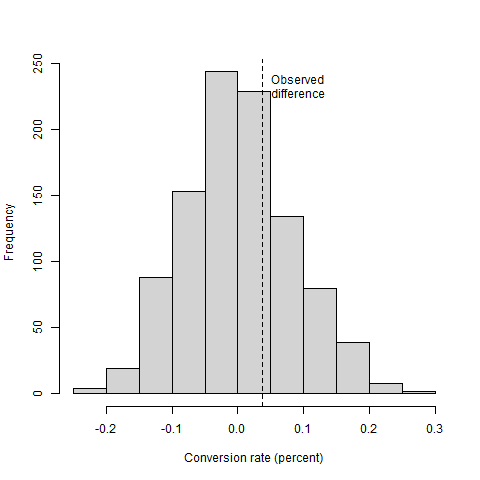

In [20]:
%%R
obs_pct_diff <- 100 * (200 / 23739 - 182 / 22588)
conversion <- c(rep(0, 45945), rep(1, 382))
perm_diffs <- rep(0, 1000)
for (i in 1:1000) {
  perm_diffs[i] = 100 * perm_fun(conversion, 23739, 22588)
}

hist(perm_diffs, xlab='Conversion rate (percent)', main='')
abline(v=obs_pct_diff, lty=2, lwd=1.5)
text('   Observed\n   difference', x=obs_pct_diff,  y=par()$usr[4]-20, adj=0)

In [21]:
%%R
# Obbserved difference
obs_pct_diff

[1] 0.03675791


## P-Value

### Python
If `np.mean` is applied to a list of booleans, it gives the percentage of how often True was found in the list (#True / #Total).

In [22]:
print(np.mean([diff > obs_pct_diff for diff in perm_diffs]))

0.332


In [23]:
survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)

print(f'p-value for single sided test: {p_value / 2:.4f}')

p-value for single sided test: 0.3498


### R

In [24]:
%%R
mean(perm_diffs > obs_pct_diff)

[1] 0.34


In [25]:
%%R
prop.test(x=c(200,182), n=c(23739,22588), alternative='greater')


	2-sample test for equality of proportions with continuity correction

data:  c(200, 182) out of c(23739, 22588)
X-squared = 0.14893, df = 1, p-value = 0.3498
alternative hypothesis: greater
95 percent confidence interval:
 -0.001057439  1.000000000
sample estimates:
     prop 1      prop 2 
0.008424955 0.008057376 



### Summary: Statistical Significance and P-Values

| Operation | Python | R | Notes |
|---|---|---|---|
| Observed conversion lift | direct arithmetic expression | direct arithmetic expression | Identical effect-size definition in both languages. |
| Permutation sampling | manual shuffled assignments | manual shuffled assignments | Both build a null distribution without strong parametric assumptions. |
| Empirical p-value | boolean mean via `np.mean(...)` | boolean mean via `mean(...)` | Same interpretation: tail-area fraction in simulated outcomes. |
| Classical benchmark test | `stats.chi2_contingency()` | `prop.test()` | Different default tests, same inferential objective. |

Both ecosystems support randomization inference and classical tests; the key practical difference is which built-in test API is typically used first.

# t-Tests

### Python

In [26]:
res = stats.ttest_ind(session_times[session_times.Page == 'Page A'].Time, 
                      session_times[session_times.Page == 'Page B'].Time,
                      equal_var=False)
print(f'p-value for single sided test: {res.pvalue / 2:.4f}')

p-value for single sided test: 0.1408


In [27]:
tstat, pvalue, df = sm.stats.ttest_ind(
    session_times[session_times.Page == 'Page A'].Time, 
    session_times[session_times.Page == 'Page B'].Time,
    usevar='unequal', alternative='smaller')
print(f'p-value: {pvalue:.4f}')

p-value: 0.1408


### R
R runs the same directional two-sample t-test using formula syntax (`t.test(Time ~ Page, ...)`).

In [28]:
%%R
t.test(Time ~ Page, data=session_times, alternative='less')


	Welch Two Sample t-test

data:  Time by Page
t = -1.0983, df = 27.693, p-value = 0.1408
alternative hypothesis: true difference in means between group Page A and group Page B is less than 0
95 percent confidence interval:
     -Inf 19.59674
sample estimates:
mean in group Page A mean in group Page B 
            126.3333             162.0000 



### Summary: t-Tests

| Operation | Python | R | Notes |
|---|---|---|---|
| Two-sample t-test | `stats.ttest_ind(...)` | `t.test(Time ~ Page, ...)` | Same hypothesis test with different interface styles. |
| Directional alternative | `alternative='less'` | `alternative='less'` | Directionality is explicit in both implementations. |
| Degrees of freedom output | `sm.stats.ttest_ind(...)` | returned in `t.test` result | Both provide test statistic context beyond p-value. |

R's formula interface is compact for grouped comparisons, while Python commonly combines SciPy and statsmodels for fuller output control.

# ANOVA

### Python

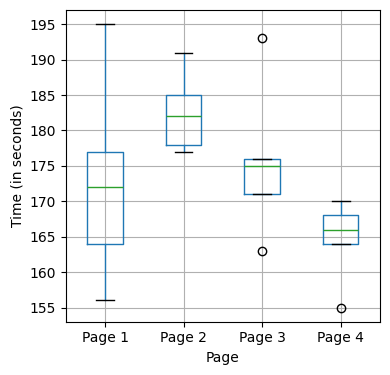

In [29]:
four_sessions = pd.read_csv(FOUR_SESSIONS_CSV)

ax = four_sessions.boxplot(by='Page', column='Time',
                           figsize=(4, 4))
ax.set_xlabel('Page')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')
plt.title('')

plt.tight_layout()
plt.show()

In [30]:
print(pd.read_csv(FOUR_SESSIONS_CSV).head())

     Page  Time
0  Page 1   164
1  Page 2   178
2  Page 3   175
3  Page 4   155
4  Page 1   172


In [31]:
observed_variance = four_sessions.groupby('Page').mean().var().iloc[0]
print('Observed means:', four_sessions.groupby('Page').mean().values.ravel())
print('Variance:', observed_variance)
# Permutation test example with stickiness
def perm_test(df):
    df = df.copy()
    df['Time'] = np.random.permutation(df['Time'].values)
    return df.groupby('Page').mean().var().iloc[0]
    
print(perm_test(four_sessions))

Observed means: [172.8 182.6 175.6 164.6]
Variance: 55.426666666666655
11.05333333333337


Pr(Prob) 0.084


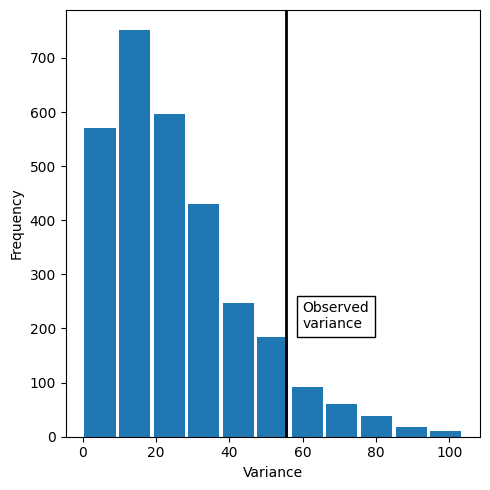

In [32]:
random.seed(1)
perm_variance = [perm_test(four_sessions) for _ in range(3000)]
print('Pr(Prob)', np.mean([var > observed_variance for var in perm_variance]))

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(x = observed_variance, color='black', lw=2)
ax.text(60, 200, 'Observed\nvariance', bbox={'facecolor':'white'})
ax.set_xlabel('Variance')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### F-Statistic - Python
We can compute an ANOVA table using statsmodel.

In [33]:
model = smf.ols('Time ~ Page', data=four_sessions).fit()
                
aov_table = sm.stats.anova_lm(model)
print(aov_table)

            df  sum_sq     mean_sq         F    PR(>F)
Page       3.0   831.4  277.133333  2.739825  0.077586
Residual  16.0  1618.4  101.150000       NaN       NaN


In [34]:
res = stats.f_oneway(four_sessions[four_sessions.Page == 'Page 1'].Time, 
                     four_sessions[four_sessions.Page == 'Page 2'].Time,
                     four_sessions[four_sessions.Page == 'Page 3'].Time,
                     four_sessions[four_sessions.Page == 'Page 4'].Time)
print(f'F-Statistic: {res.statistic / 2:.4f}')
print(f'p-value: {res.pvalue / 2:.4f}')

F-Statistic: 1.3699
p-value: 0.0388


#### Two-way anova only available with statsmodels
```
formula = 'len ~ C(supp) + C(dose) + C(supp):C(dose)'
model = ols(formula, data).fit()
aov_table = anova_lm(model, typ=2)
```

### R
R visualizes group distributions and runs permutation ANOVA with `aovp` from `lmPerm`.

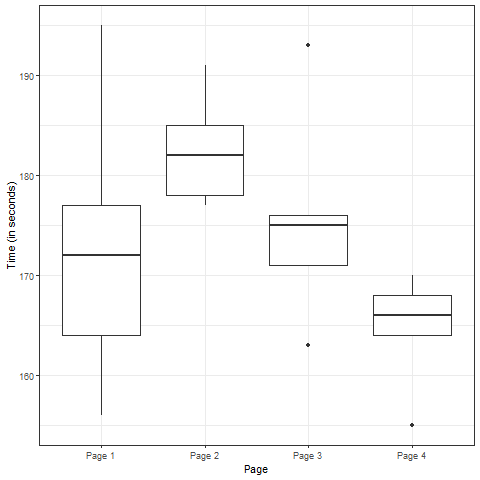

In [35]:
%%R
graph <- ggplot(four_sessions, aes(x=Page, y=Time)) + 
  geom_boxplot() +
  labs(y='Time (in seconds)') +
  theme_bw()
graph

In [36]:
%%R
library(lmPerm)
summary(aovp(Time ~ Page, data=four_sessions))

[1] "Settings:  unique SS "
Component 1 :
            Df R Sum Sq R Mean Sq Iter Pr(Prob)    
Page1        3    831.4    277.13 5000    0.001 ***
Residuals   16   1618.4    101.15                  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1



### F-Statistic - R

In [37]:
%%R
summary(aov(Time ~ Page, data=four_sessions))

            Df Sum Sq Mean Sq F value Pr(>F)  
Page         3  831.4   277.1    2.74 0.0776 .
Residuals   16 1618.4   101.2                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


### Summary: ANOVA and F-Statistic

| Operation | Python | R | Notes |
|---|---|---|---|
| Group means and spread check | `groupby()` + custom variance metric | boxplot in `ggplot2` | Both start with exploratory between-group structure. |
| Permutation ANOVA | custom `perm_test` simulation | `lmPerm::aovp(...)` | Python builds simulation explicitly; R provides a dedicated permutation ANOVA API. |
| Classical ANOVA table | `sm.stats.anova_lm(...)` | `summary(aov(...))` | Standard F-statistic workflow in both languages. |
| One-way F test helper | `stats.f_oneway(...)` | via `aov` summary | Equivalent one-way significance framing. |

Python offers granular procedural control, while R's statistical modeling packages provide concise high-level ANOVA calls.

# Chi-Square Test
## Chi-Square Test: A Resampling Approach

### Python

In [38]:
# Table 3-4
click_rate = pd.read_csv(CLICK_RATE_CSV)
clicks = click_rate.pivot(index='Click', columns='Headline', values='Rate')
print(clicks)

Headline  Headline A  Headline B  Headline C
Click                                       
Click             14           8          12
No-click         986         992         988


In [39]:
# Table 3-5
row_average = clicks.mean(axis=1)
pd.DataFrame({
    'Headline A': row_average,
    'Headline B': row_average,
    'Headline C': row_average,
})

,Headline A,Headline B,Headline C
Click,,,
Click,11.333333,11.333333,11.333333
No-click,988.666667,988.666667,988.666667


In [40]:
# Resampling approach
box = [1] * 34
box.extend([0] * 2966)
random.shuffle(box)

def chi2(observed, expected):
    pearson_residuals = []
    for row, expect in zip(observed, expected):
        pearson_residuals.append([(observe - expect) ** 2 / expect
                                  for observe in row])
    # return sum of squares
    return np.sum(pearson_residuals)

expected_clicks = 34 / 3
expected_noclicks = 1000 - expected_clicks
expected = [expected_clicks, expected_noclicks]
chi2observed = chi2(clicks.values, expected)

def perm_fun(box):
    random.shuffle(box)
    sample_clicks = [sum(box[0:1000]),
                     sum(box[1000:2000]),
                     sum(box[2000:3000])]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [perm_fun(box) for _ in range(2000)]

resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4660


In [41]:
chisq, pvalue, df, expected = stats.chi2_contingency(clicks)
print(f'Observed chi2: {chisq:.4f}')
print(f'p-value: {pvalue:.4f}')

Observed chi2: 1.6659
p-value: 0.4348


The above algorithm uses sampling into the three sets without replacement. Alternatively, it is also possible to sample with replacement.

In [42]:
expected = [expected_clicks, expected_noclicks]
def sample_with_replacement(box):
    sample_clicks = [sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000))]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [sample_with_replacement(box) for _ in range(2000)]

resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4845


#### Figure chi-sq distribution

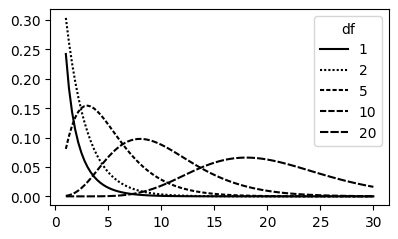

In [43]:
x = [1 + i * (30 - 1) / 99 for i in range(100)]

chi = pd.DataFrame({
    'x': x,
    'chi_1': stats.chi2.pdf(x, df=1),
    'chi_2': stats.chi2.pdf(x, df=2),
    'chi_5': stats.chi2.pdf(x, df=5),
    'chi_10': stats.chi2.pdf(x, df=10),
    'chi_20': stats.chi2.pdf(x, df=20),
})
fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(chi.x, chi.chi_1, color='black', linestyle='-', label='1')
ax.plot(chi.x, chi.chi_2, color='black', linestyle=(0, (1, 1)), label='2')
ax.plot(chi.x, chi.chi_5, color='black', linestyle=(0, (2, 1)), label='5')
ax.plot(chi.x, chi.chi_10, color='black', linestyle=(0, (3, 1)), label='10')
ax.plot(chi.x, chi.chi_20, color='black', linestyle=(0, (4, 1)), label='20')
ax.legend(title='df')

plt.tight_layout()
plt.show()

#### Fisher's Exact Test
Scipy has only an implementation of Fisher's Exact test for 2x2 matrices. There is a github repository that provides a Python implementation that uses the same code as the R version. Installing this requires a Fortran compiler. 
```
stats.fisher_exact(clicks)
```

In [44]:
# stats.fisher_exact(clicks.values)

#### Scientific Fraud

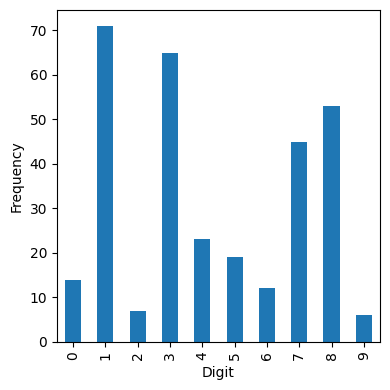

In [45]:
imanishi = pd.read_csv(IMANISHI_CSV)
imanishi.columns = [c.strip() for c in imanishi.columns]
ax = imanishi.plot.bar(x='Digit', y=['Frequency'], legend=False,
                      figsize=(4, 4))
ax.set_xlabel('Digit')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### R
R builds the contingency table and evaluates independence with `chisq.test()`.

In [46]:
%%R
clicks <- matrix(click_rate$Rate, nrow=3, ncol=2, byrow=TRUE)
dimnames(clicks) <- list(unique(click_rate$Headline), unique(click_rate$Click))

chisq.test(clicks, simulate.p.value=TRUE)


	Pearson's Chi-squared test with simulated p-value (based on 2000
	replicates)

data:  clicks
X-squared = 1.6659, df = NA, p-value = 0.4813



In [47]:
%%R
chisq.test(clicks, simulate.p.value=FALSE)


	Pearson's Chi-squared test

data:  clicks
X-squared = 1.6659, df = 2, p-value = 0.4348



#### Figure chi-sq distribution

R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In geom_text(aes(x = 25, y = 0.06, label = "df=20"), size = 2.5) :  
R callback write-console: 
   
R callback write-console:  All aesthetics have length 1, but the data has 400 rows.
i Please consider using `annotate()` or provide this layer with data containing a single row.
  
R callback write-console: 2:   
R callback write-console: In geom_text(aes(x = 8, y = 0.1, label = "df=5"), size = 2.5) :  
R callback write-console: 
   
R callback write-console:  All aesthetics have length 1, but the data has 400 rows.
i Please consider using `annotate()` or provide this layer with data containing a single row.
  
R callback write-console: 3:   
R callback write-console: In geom_text(aes(x = 4, y = 0.2, label = "df=2"), size = 2.5) :  
R callback write-console: 
   
R callback write-console:  All aesthetics have length 1, but the data has 400 row

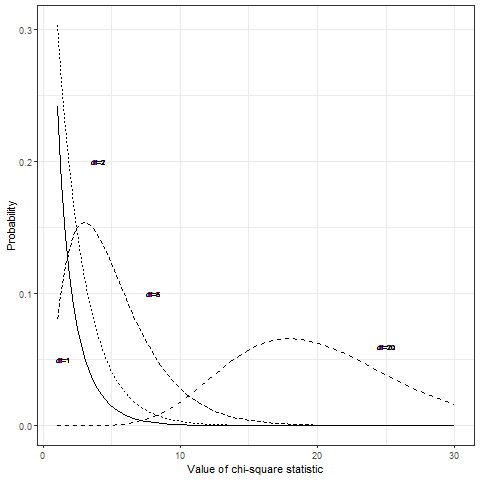

In [48]:
%%R
x <- seq(1, 30, length=100)
chi <- data.frame(df = factor(rep(c(1, 2, 5, 20), rep(100, 4))),
                  x = rep(x, 4),
                  p = c(dchisq(x, 1), dchisq(x, 2), dchisq(x, 5), dchisq(x, 20)))

graph <- ggplot(chi, aes(x=x, y=p)) +
  geom_line(aes(linetype=df)) +
  geom_text(aes(x=25, y=0.06, label='df=20'), size=2.5) +
  geom_text(aes(x=8, y=0.1, label='df=5'), size=2.5) +
  geom_text(aes(x=4, y=0.2, label='df=2'), size=2.5) +
  geom_text(aes(x=1.5, y=0.05, label='df=1'), size=2.5) +
  theme_bw() + theme(legend.position = "none") +
  labs(x='Value of chi-square statistic', y='Probability')
graph

#### Fisher's Exact Test

In [49]:
%%R
fisher.test(clicks)


	Fisher's Exact Test for Count Data

data:  clicks
p-value = 0.4824
alternative hypothesis: two.sided



#### Scientific Fraud

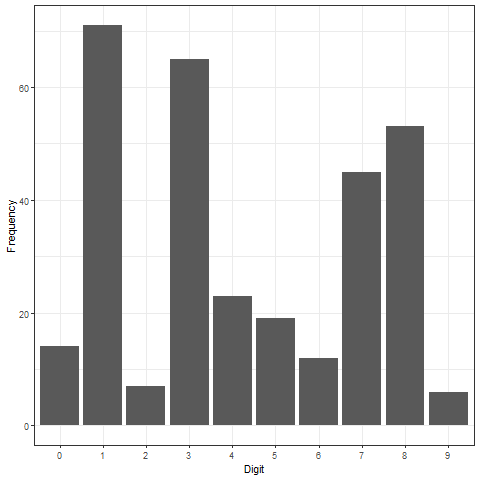

In [50]:
%%R
## Code for Figure 8
imanishi$Digit <- factor(imanishi$Digit)

graph <- ggplot(imanishi, aes(x=Digit, y=Frequency)) +
  geom_bar(stat='identity') +
  theme_bw()
graph

### Summary: Chi-Square, Fisher's Exact Test, and Scientific-Fraud Simulation

| Operation | Python | R | Notes |
|---|---|---|---|
| Contingency table setup | `DataFrame` reshaping to matrix | `matrix(..., byrow=TRUE)` | Same data structure for count-based tests. |
| Chi-square test | `stats.chi2_contingency()` | `chisq.test()` | Equivalent test of independence. |
| Reference chi-square density | `stats.chi2.pdf()` + matplotlib | `dchisq()` + base plot | Same theoretical distribution visualization. |
| Fisher exact test | `stats.fisher_exact()` (2x2) | `fisher.test()` | R has broader built-in support for exact tests. |
| p-value simulation study | repeated Monte Carlo sampling | repeated simulation loop in R | Both reproduce p-value distribution behavior under repeated testing. |

The statistical goals are aligned, but R offers a more complete built-in exact-testing toolchain, whereas Python often relies on SciPy's narrower defaults.

# Power and Sample Size

### Python
statsmodels has a number of methods for power calculation

see e.g.: https://machinelearningmastery.com/statistical-power-and-power-analysis-in-python/

In [51]:
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size, 
                              alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 116602.391


In [52]:
effect_size = sm.stats.proportion_effectsize(0.0165, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size, 
                              alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 5488.408


### R
R computes effect sizes with `ES.h()` and solves sample-size requirements with `pwr.2p.test()`.

In [53]:
%%R
effect_size = ES.h(p1=0.0121, p2=0.011)
pwr.2p.test(h=effect_size, sig.level=0.05, power=0.8, alternative='greater')


     Difference of proportion power calculation for binomial distribution (arcsine transformation) 

              h = 0.01029785
              n = 116601.7
      sig.level = 0.05
          power = 0.8
    alternative = greater

NOTE: same sample sizes



In [54]:
%%R
effect_size = ES.h(p1=0.0165, p2=0.011)
pwr.2p.test(h=effect_size, sig.level=0.05, power=0.8, alternative='greater')


     Difference of proportion power calculation for binomial distribution (arcsine transformation) 

              h = 0.04746819
              n = 5487.731
      sig.level = 0.05
          power = 0.8
    alternative = greater

NOTE: same sample sizes



### Summary: Power and Sample Size

| Operation | Python | R | Notes |
|---|---|---|---|
| Effect size for proportions | `sm.stats.proportion_effectsize()` | `pwr::ES.h()` | Same Cohen's h effect-size concept. |
| Solve for sample size | `TTestIndPower.solve_power(...)` | `pwr.2p.test(...)` | Both compute required N from effect, alpha, and target power. |
| Sensitivity scenario | second call with larger effect | second call with larger effect | Both show lower N requirements for larger effects. |

Both libraries provide practical power-analysis workflows; R keeps them in one package family, while Python composes them from statsmodels utilities.